Loaded: fieldfox_beatnote_20260818_235159.npz
Number of traces : 1256
Measurement time : 2322.13 s
Frequency span   : 0.100 kHz

Mean peak frequency : 6141.012228016 MHz
Standard deviation  : 0.512 Hz
Peak-to-peak        : 3.750 Hz


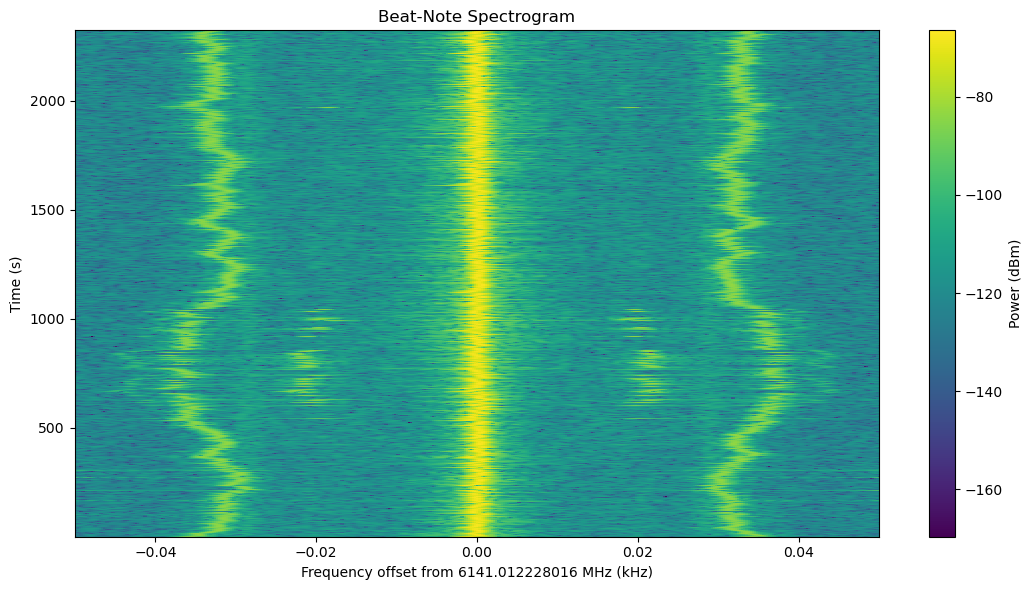

1256 1256


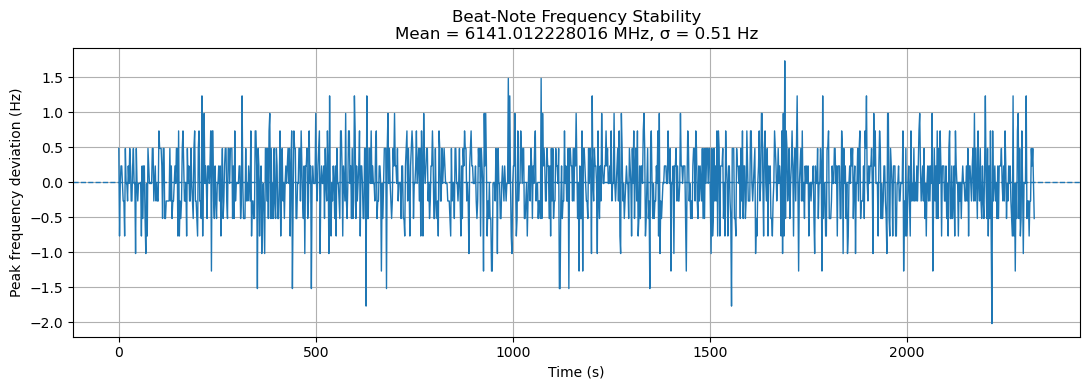

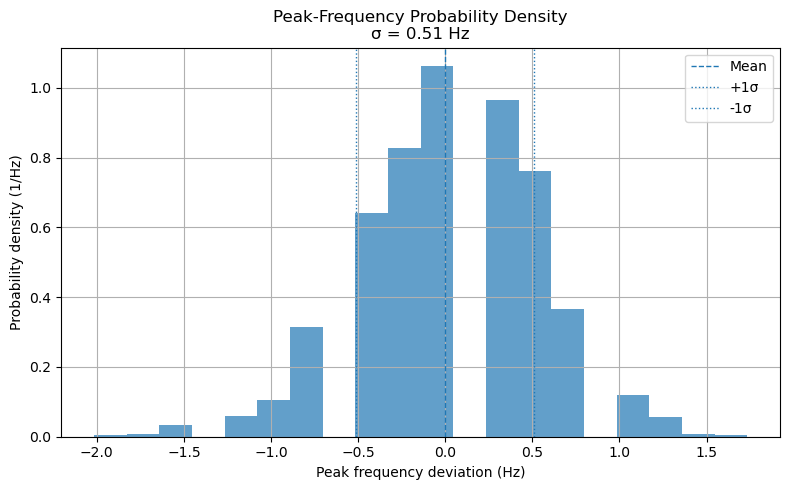

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD SAVED MEASUREMENT
# --------------------------------------------------
filename = "fieldfox_beatnote_20260818_191351.npz"  # 106th without clock rep-rate enabled
#filename = "fieldfox_beatnote_20260818_194748.npz"  # 106th with clock rep-rate enabled
filename = "fieldfox_beatnote_20260818_224340.npz"  # 106th with clock rep-rate disabled, 10 kHz span
filename = "fieldfox_beatnote_20260818_232252.npz"  # 81st with clock rep-rate disabled, 5 kHz span
filename = "fieldfox_beatnote_20260818_233800.npz"  # 81st with clock rep-rate disabled, 5 kHz span
filename = "fieldfox_beatnote_20260818_235159.npz"  # 81st with clock rep-rate disabled, 5 kHz span
data = np.load(filename)

freq = data["frequency_hz"]
spectra = data["spectra"]
t = data["time_s"]

peak_freq = data["peak_frequency_hz"]
peak_power = data["peak_power_dbm"]

print(f"Loaded: {filename}")
print(f"Number of traces : {len(t)}")
print(f"Measurement time : {t[-1] - t[0]:.2f} s")
print(f"Frequency span   : {(freq[-1]-freq[0])/1e3:.3f} kHz")


# --------------------------------------------------
# PEAK-FREQUENCY STATISTICS
# --------------------------------------------------

mean_freq = np.mean(peak_freq)
freq_error = peak_freq - mean_freq

print()
print(f"Mean peak frequency : {mean_freq/1e6:.9f} MHz")
print(f"Standard deviation  : {np.std(freq_error):.3f} Hz")
print(f"Peak-to-peak        : {np.ptp(freq_error):.3f} Hz")


# ==================================================
# 1. SPECTROGRAM
# ==================================================

fig, ax = plt.subplots(figsize=(11, 6))

im = ax.imshow(
    spectra,
    origin="lower",
    aspect="auto",
    extent=[
        (freq[0] - mean_freq) / 1e3,
        (freq[-1] - mean_freq) / 1e3,
        t[0],
        t[-1]
    ],
    interpolation="nearest"
)

# overlay measured peak position
# ax.plot(
#     freq_error / 1e3,
#     t,
#     linewidth=1,
#     label="Peak"
# )

ax.set_xlabel(
    f"Frequency offset from {mean_freq/1e6:.9f} MHz (kHz)"
)

ax.set_ylabel("Time (s)")
ax.set_title("Beat-Note Spectrogram")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Power (dBm)")

plt.tight_layout()
plt.show()


# ==================================================
# 2. PEAK FREQUENCY vs TIME
# ==================================================

fig, ax = plt.subplots(figsize=(11, 4))
print(len(t), len(freq_error))
ax.plot(
    t,
    freq_error,
    linewidth=1
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Peak frequency deviation (Hz)")

ax.set_title(
    f"Beat-Note Frequency Stability\n"
    f"Mean = {mean_freq/1e6:.9f} MHz, "
    f"σ = {np.std(freq_error):.2f} Hz"
)

ax.grid(True)

plt.tight_layout()
plt.show()


# ==================================================
# 3. PROBABILITY DENSITY OF PEAK FREQUENCY
# ==================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    freq_error,
    bins= 20,
    density=True,
    alpha=0.7
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    label="Mean"
)

ax.axvline(
    np.std(freq_error),
    linestyle=":",
    linewidth=1,
    label="+1σ"
)

ax.axvline(
    -np.std(freq_error),
    linestyle=":",
    linewidth=1,
    label="-1σ"
)

ax.set_xlabel("Peak frequency deviation (Hz)")
ax.set_ylabel("Probability density (1/Hz)")

ax.set_title(
    f"Peak-Frequency Probability Density\n"
    f"σ = {np.std(freq_error):.2f} Hz"
)

ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

Voigt fit results
-----------------
Number of bins         = 16
Bin width              = 0.234 Hz
Center                 = 0.016 Hz
Gaussian sigma         = 0.470 ± 0.095 Hz
Gaussian FWHM          = 1.107 Hz
Lorentzian FWHM        = 0.000 ± 0.444 Hz
Voigt FWHM             = 1.107 Hz


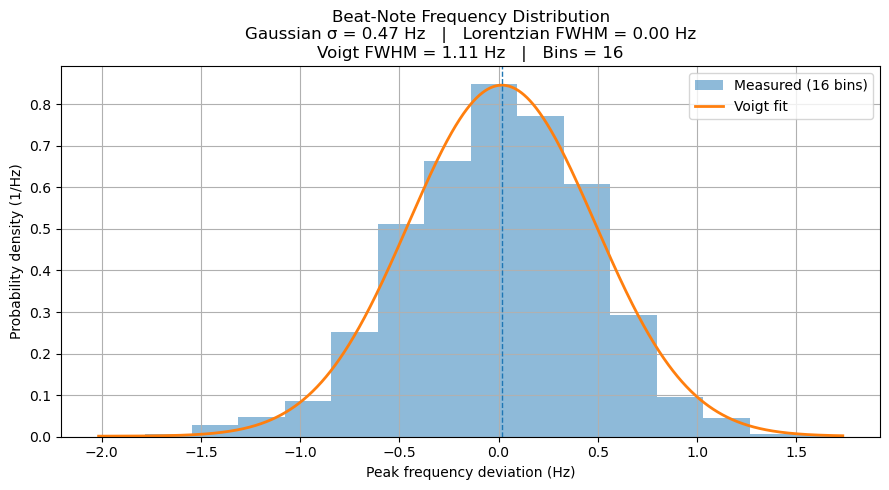

In [61]:
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# ==================================================
# VOIGT FIT TO PEAK-FREQUENCY DISTRIBUTION
# ==================================================

bin_val = 16   # <-- choose number of histogram bins here

# Histogram
counts, edges = np.histogram(
    freq_error,
    bins=bin_val,
    density=True
)

x_hist = 0.5 * (edges[:-1] + edges[1:])
bin_width = np.mean(np.diff(edges))


# --------------------------------------------------
# Voigt model
#
# sigma = Gaussian standard deviation
# gamma = Lorentzian HWHM
# therefore Lorentzian FWHM = 2*gamma
# --------------------------------------------------

def voigt_fit(x, amplitude, center, sigma, gamma, offset):
    return (
        amplitude * voigt_profile(x - center, sigma, gamma)
        + offset
    )


# Initial guesses
center_guess = np.mean(freq_error)
sigma_guess = np.std(freq_error) / 2
gamma_guess = max(bin_width, np.std(freq_error) / 4)
amplitude_guess = 1.0
offset_guess = 0.0

p0 = [
    amplitude_guess,
    center_guess,
    sigma_guess,
    gamma_guess,
    offset_guess
]

# Force sigma and gamma positive
bounds = (
    [0, -np.inf, 0, 0, 0],
    [np.inf, np.inf, np.inf, np.inf, np.inf]
)

popt, pcov = curve_fit(
    voigt_fit,
    x_hist,
    counts,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

amplitude, center, sigma_G, gamma_L, offset = popt


# ==================================================
# WIDTHS
# ==================================================

# Lorentzian FWHM
lorentzian_fwhm = 2 * gamma_L

# Gaussian FWHM
gaussian_fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma_G

# Voigt FWHM approximation
voigt_fwhm = (
    0.5346 * lorentzian_fwhm
    + np.sqrt(
        0.2166 * lorentzian_fwhm**2
        + gaussian_fwhm**2
    )
)


# ==================================================
# PARAMETER UNCERTAINTIES
# ==================================================

perr = np.sqrt(np.diag(pcov))

sigma_G_err = perr[2]
gamma_L_err = perr[3]

lorentzian_fwhm_err = 2 * gamma_L_err


# ==================================================
# PRINT RESULTS
# ==================================================

print("Voigt fit results")
print("-----------------")

print(f"Number of bins         = {bin_val}")
print(f"Bin width              = {bin_width:.3f} Hz")

print(f"Center                 = {center:.3f} Hz")

print(
    f"Gaussian sigma         = "
    f"{sigma_G:.3f} ± {sigma_G_err:.3f} Hz"
)

print(
    f"Gaussian FWHM          = "
    f"{gaussian_fwhm:.3f} Hz"
)

print(
    f"Lorentzian FWHM        = "
    f"{lorentzian_fwhm:.3f} ± "
    f"{lorentzian_fwhm_err:.3f} Hz"
)

print(
    f"Voigt FWHM             = "
    f"{voigt_fwhm:.3f} Hz"
)


# ==================================================
# PLOT
# ==================================================

x_fit = np.linspace(
    edges[0],
    edges[-1],
    2000
)

y_fit = voigt_fit(x_fit, *popt)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    freq_error,
    bins=bin_val,
    density=True,
    alpha=0.5,
    label=f"Measured ({bin_val} bins)"
)

ax.plot(
    x_fit,
    y_fit,
    linewidth=2,
    label="Voigt fit"
)

ax.axvline(
    center,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Peak frequency deviation (Hz)")
ax.set_ylabel("Probability density (1/Hz)")

ax.set_title(
    "Beat-Note Frequency Distribution\n"
    f"Gaussian σ = {sigma_G:.2f} Hz   |   "
    f"Lorentzian FWHM = {lorentzian_fwhm:.2f} Hz\n"
    f"Voigt FWHM = {voigt_fwhm:.2f} Hz   |   "
    f"Bins = {bin_val}"
)

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()